________________________

## M10-Evaluation

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/data/vserrano/cbc_pe/data")
DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

M10_TAG = "M10_inputzscore_resdilated_emb64_d124_train400k"

HISTORY_PATH = DATA_ROOT / "results" / DATASET_ID / (
    f"{DATASET_ID}_SimpleCNN_ResidualDilated_"
    f"{M10_TAG}_MSELoss_seed123_history.npz"
)

PRED_PATH = DATA_ROOT / "results" / DATASET_ID / (
    "m10_inputzscore_500k_cal_test_predictions_embeddings.npz"
)

OUTPUT_DIR = DATA_ROOT / "results" / DATASET_ID / "m10_inputzscore_500k_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("HISTORY_PATH:", HISTORY_PATH, HISTORY_PATH.exists())
print("PRED_PATH:", PRED_PATH, PRED_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

In [ ]:
hist = np.load(HISTORY_PATH)

print(hist.files)

for k in hist.files:
    print(k, hist[k].shape, hist[k].dtype)

train_loss = hist["train_loss"]
val_loss = hist["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)
best_epoch = int(np.argmin(val_loss) + 1)
best_val = float(np.min(val_loss))

print("best_epoch:", best_epoch)
print("best_val:", best_val)

['train_loss', 'val_loss', 'train_time', 'val_time', 'epoch_time']
train_loss (101,) [0.64110001 0.50076482 0.45654271 0.37467219 0.31392465]
val_loss (101,) [0.52797947 0.49348796 0.45453753 0.31046701 0.26429765]
train_time (101,) [420.97878265 413.73676968 400.0039072  356.15587211 297.45551658]
val_time (101,) [ 92.22378802  97.12616873 102.97652149 101.00639367  51.90446353]
epoch_time (101,) [513.20257282 510.86294174 502.98043227 457.16226935 349.35998344]


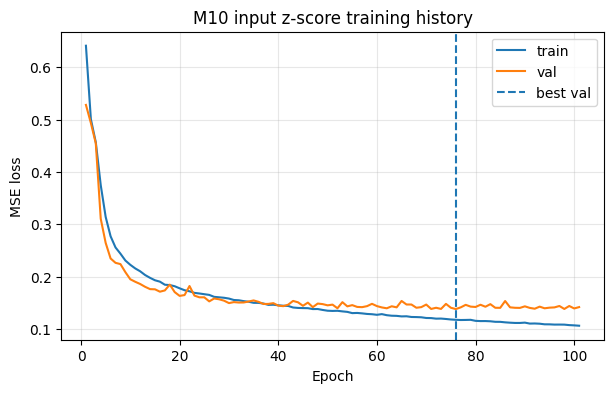

best epoch: 76
best val: 0.13785006055831908


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("M10 input-zscore 500k training history")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = OUTPUT_DIR / "m10_500k_train_val_loss.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

### Load preds cal/test

In [ ]:
if not PRED_PATH.exists():
    raise FileNotFoundError(
        f"Prediction file not found yet:\n{PRED_PATH}\n\n"
        "Run scripts/predict_cnn_hdf5.py after training finishes."
    )

pred_data = np.load(PRED_PATH, allow_pickle=True)

print("Files:")
for k in pred_data.files:
    arr = pred_data[k]
    print(f"{k:25s}", arr.shape, arr.dtype)

In [ ]:
pred_cal_std = pred_data["pred_cal"].astype(np.float32)
y_cal_std = pred_data["y_cal"].astype(np.float32)
emb_cal = pred_data["emb_cal"].astype(np.float32)

pred_test_std = pred_data["pred_test"].astype(np.float32)
y_test_std = pred_data["y_test"].astype(np.float32)
emb_test = pred_data["emb_test"].astype(np.float32)

y_mean = pred_data["y_mean"].astype(np.float32)
y_std = pred_data["y_std"].astype(np.float32)
label_names = [str(x) for x in pred_data["label_names"].tolist()]

input_normalization = pred_data["input_normalization"].item()

print("label_names:", label_names)
print("input_normalization:", input_normalization)

assert input_normalization["enabled"] is True
assert input_normalization["mode"] == "per_sample_per_detector_zscore"

print("pred_cal_std:", pred_cal_std.shape)
print("pred_test_std:", pred_test_std.shape)
print("emb_cal:", emb_cal.shape)
print("emb_test:", emb_test.shape)

In [ ]:
def inverse_label_standardization(y_std_values, y_mean, y_std):
    return y_std_values * y_std[None, :] + y_mean[None, :]

pred_cal_phys = inverse_label_standardization(pred_cal_std, y_mean, y_std)
y_cal_phys = inverse_label_standardization(y_cal_std, y_mean, y_std)

pred_test_phys = inverse_label_standardization(pred_test_std, y_mean, y_std)
y_test_phys = inverse_label_standardization(y_test_std, y_mean, y_std)

X_batch shape: (16, 3, 16384)
Before z-score
means: [[ 0.00524662  0.00229446 -0.00554621]
 [ 0.00581607  0.00784029 -0.01968945]
 [-0.00353929 -0.02061439  0.00413047]
 [ 0.02346002 -0.0150696  -0.00248801]
 [-0.00241953 -0.01210421 -0.00099267]]
stds: [[22.159405 21.877266 21.83404 ]
 [22.37847  23.03308  21.972206]
 [22.682234 22.592485 22.245266]
 [22.224697 22.118368 21.574474]
 [22.347122 21.585777 22.10776 ]]

After z-score
means: [[ 6.2282197e-09  9.3132257e-09  1.0244548e-08]
 [-2.0809239e-09 -2.4738256e-09 -8.1781764e-09]
 [ 1.1263182e-08  8.8475645e-09 -1.4028046e-08]
 [-1.0186341e-08 -1.7753337e-09 -1.6967533e-08]
 [ 6.1700121e-09 -5.8207661e-09 -1.7724233e-08]]
stds: [[0.9999999  0.9999999  0.9999999 ]
 [0.99999994 0.99999994 0.99999994]
 [0.9999999  0.99999994 0.9999999 ]
 [0.9999999  0.9999999  0.9999999 ]
 [0.99999994 0.99999994 0.9999999 ]]

Summary
mean abs channel mean: 6.6211214e-09
mean channel std: 0.99999994


In [ ]:
def regression_metrics(y_true, y_pred, label_names):
    rows = []

    for j, name in enumerate(label_names):
        err = y_pred[:, j] - y_true[:, j]

        mse = np.mean(err**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(err))
        bias = np.mean(err)

        ss_res = np.sum(err**2)
        ss_tot = np.sum((y_true[:, j] - np.mean(y_true[:, j]))**2)
        r2 = 1.0 - ss_res / ss_tot

        rows.append({
            "label": name,
            "rmse": float(rmse),
            "mae": float(mae),
            "bias": float(bias),
            "r2": float(r2),
        })

    return pd.DataFrame(rows)

metrics_std_df = regression_metrics(y_test_std, pred_test_std, label_names)
metrics_phys_df = regression_metrics(y_test_phys, pred_test_phys, label_names)

display(metrics_std_df)
display(metrics_phys_df)

metrics_std_df.to_csv(OUTPUT_DIR / "m10_500k_test_metrics_std.csv", index=False)
metrics_phys_df.to_csv(OUTPUT_DIR / "m10_500k_test_metrics_phys.csv", index=False)